# Segmentación semántica de SuperTuxKart con SAM 2

**Proyecto Final · Visión Artificial 202610 · USFQ**

Transfer learning desde **Segment Anything Model 2** para clasificar cada píxel de un frame
del videojuego en una de 7 clases: `background`, `track`, `kart`, `pickup`, `nitro`, `bomb`,
`projectile`.

## Por qué SAM 2 no sirve tal cual

SAM 2 **no es un segmentador semántico**. Es *promptable* y *binario*: recibe una imagen más
un prompt (un punto, una caja) y devuelve la máscara del objeto señalado. No sabe qué es un
kart ni distingue siete clases.

Lo que sí tiene es un **image encoder** (Hiera + cuello FPN) entrenado sobre millones de
máscaras, cuyas features separan objetos, bordes y superficies con mucha precisión.

El transfer learning consiste en:

1. Usar ese encoder **congelado** como extractor de features.
2. Descartar la *memory attention* (es para vídeo) y el *mask decoder* original (es binario).
3. Entrenar **una cabeza nueva** que fusione los tres niveles del FPN y produzca 7 logits por píxel.

## 1. Preparación

In [1]:
import os, sys, json, random
import numpy as np
import torch
import matplotlib.pyplot as plt

sys.path.insert(0, os.getcwd())
from utils import (CLASS_NAMES, NUM_CLASSES, VAL_TRACKS, PALETTE, ConfusionMatrix,
                   STKSegmentationDataset, split_tracks, load_data, label_to_color,
                   overlay, format_iou_table, format_confusion, weights_from_counts)

DATA_ROOT = 'data'
device = 'cuda' if torch.cuda.is_available() else ('mps' if torch.backends.mps.is_available() else 'cpu')
print('torch', torch.__version__, '| device', device)

torch 2.14.0 | device mps


## 2. El dataset

1500 frames etiquetados de 6 circuitos, 400×400 RGB. Las máscaras son imágenes de 1 canal
donde **el valor del píxel es directamente el índice de clase** (0 a 6).

Dos reglas de carga que, si se incumplen, rompen el entrenamiento en silencio:

- La máscara **no se convierte a RGB ni se normaliza**. Un `ToTensor()` la dividiría entre
  255 y destruiría la codificación de clases.
- Al redimensionar se usa **NEAREST**, nunca interpolación. Interpolar etiquetas inventa
  clases inexistentes en los bordes entre objetos.

In [2]:
train_tracks = split_tracks(DATA_ROOT, 'train')
val_tracks   = split_tracks(DATA_ROOT, 'val')
train_ds = STKSegmentationDataset(DATA_ROOT, train_tracks, size=(448, 448))
val_ds   = STKSegmentationDataset(DATA_ROOT, val_tracks,   size=(448, 448))

print('circuitos entrenamiento :', train_tracks)
print('circuitos validacion    :', val_tracks)
print('frames  entrenamiento   :', len(train_ds))
print('frames  validacion      :', len(val_ds))

img, mask = train_ds[0]
print()
print('imagen  :', tuple(img.shape), img.dtype, '| rango [%.2f, %.2f]' % (img.min(), img.max()))
print('mascara :', tuple(mask.shape), mask.dtype, '| clases presentes', mask.unique().tolist())

circuitos entrenamiento : ['abyss', 'gran_paradiso_island', 'hacienda', 'olivermath']
circuitos validacion    : ['lighthouse', 'volcano_island']
frames  entrenamiento   : 1000
frames  validacion      : 500

imagen  : (3, 448, 448) torch.float32 | rango [0.01, 1.00]
mascara : (448, 448) torch.int64 | clases presentes [0, 1, 2, 3]


### El split es por circuito, no por frame

Los frames de un mismo circuito son casi idénticos entre sí — el kart avanza unos centímetros
por frame. Con un split aleatorio, el conjunto de validación contendría frames prácticamente
gemelos de los de entrenamiento y el mIoU saldría alto y **falso**.

Se reservan dos circuitos completos. `volcano_island` va a validación porque es el único que
contiene las 7 clases, así que todas son medibles.

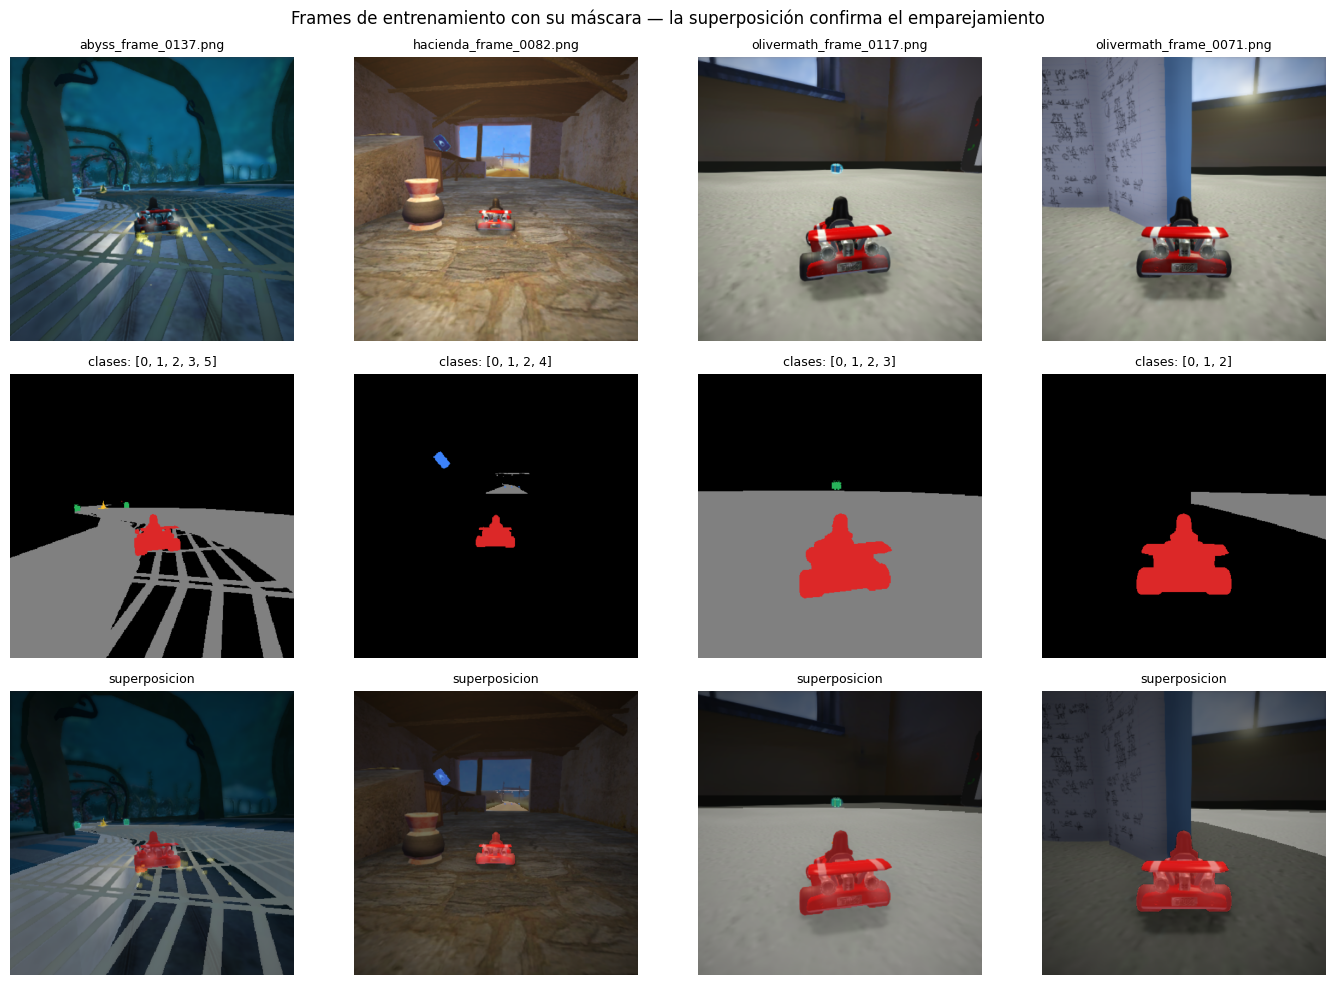

In [3]:
fig, axes = plt.subplots(3, 4, figsize=(14, 10))
for col, i in enumerate(random.Random(1).sample(range(len(train_ds)), 4)):
    im, mk = train_ds[i]
    axes[0, col].imshow(im.permute(1, 2, 0).numpy())
    axes[0, col].set_title(os.path.basename(train_ds.samples[i][0]), fontsize=9)
    axes[1, col].imshow(label_to_color(mk.numpy()))
    axes[1, col].set_title('clases: %s' % mk.unique().tolist(), fontsize=9)
    axes[2, col].imshow(overlay(im.numpy(), mk.numpy()))
    axes[2, col].set_title('superposicion', fontsize=9)
    for r in range(3): axes[r, col].axis('off')
fig.suptitle('Frames de entrenamiento con su máscara — la superposición confirma el emparejamiento', fontsize=12)
fig.tight_layout(); plt.show()

### Desbalance de clases

Es extremo, y define todo el diseño.

In [4]:
d = json.load(open('class_weights.json'))
counts = np.array(d['pixel_counts'])
pct = 100 * counts / counts.sum()
frames = np.zeros(NUM_CLASSES, dtype=int)
for i in range(len(train_ds)):
    frames[np.unique(train_ds[i][1].numpy())] += 1

w = weights_from_counts(counts, power=0.30)
print('%-12s %14s %10s %9s %8s' % ('clase', 'pixeles', '% pixeles', 'frames', 'peso'))
print('-' * 58)
for i, n in enumerate(CLASS_NAMES):
    print('%-12s %14d %10.5f %9d %8.4f' % (n, counts[i], pct[i], frames[i], w[i]))

clase               pixeles  % pixeles    frames     peso
----------------------------------------------------------
background         35104083   53.56458      1000   0.1571
track              28717785   43.81986      1000   0.1669
kart                1597638    2.43780      1000   0.3970
pickup                80568    0.12294       433   0.9726
nitro                 16789    0.02562       394   1.5570
bomb                  12332    0.01882       168   1.7080
projectile             6805    0.01038         1   2.0415


Tres consecuencias que condicionan el resto del proyecto:

1. Un modelo que prediga «todo es background o track» acierta el **97%** de los píxeles y es
   inútil. Por eso la métrica es **IoU por clase**, nunca *accuracy*.
2. Hace falta ponderar la `CrossEntropyLoss`. Se usa `peso = (1/frecuencia)^0.30`, normalizado
   a media 1. El inverso puro daría a `projectile` un peso de miles y desestabilizaría el
   entrenamiento.
3. **`projectile` aparece en 1 solo frame de los 1000 de entrenamiento** y `bomb` en 168. Su
   IoU bajo será falta de datos, no del modelo.

## 3. El modelo

El encoder de SAM 2 devuelve `backbone_fpn`: **3 niveles de 256 canales** a strides 4, 8 y 16.
La cabeza los fusiona de grueso a fino al estilo FPN y termina en una convolución 1×1 a 7 clases.

- **Entrada** cruda en `[0,1]`. La normalización de SAM 2 se aplica *dentro* del `forward`,
  como buffers, para que viaje con los pesos.
- **Salida** logits crudos, sin softmax: `CrossEntropyLoss` los espera así.
- El encoder corre bajo `torch.no_grad()`, lo que evita construir el grafo de autograd de
  34 M de parámetros que no se van a actualizar.

In [5]:
from models import SAM2Segmenter, save_model, load_model

modelo = SAM2Segmenter(backbone='small', image_size=448, dim=128, freeze_encoder=True)

entrenables = sum(p.numel() for p in modelo.parameters() if p.requires_grad)
congelados  = sum(p.numel() for p in modelo.parameters() if not p.requires_grad)
print('parametros entrenables (la cabeza) : %9d  (%.2f M)' % (entrenables, entrenables/1e6))
print('parametros congelados  (SAM 2)     : %9d  (%.2f M)' % (congelados,  congelados/1e6))
print('proporcion entrenada               : %.1f%%' % (100*entrenables/(entrenables+congelados)))

assert entrenables == sum(p.numel() for p in modelo.head.parameters()), \
    'hay parametros entrenables fuera de la cabeza'
print('\nVerificado: no hay ni un parametro entrenable fuera de la cabeza.')

parametros entrenables (la cabeza) :    690439  (0.69 M)
parametros congelados  (SAM 2)     :  34316992  (34.32 M)
proporcion entrenada               : 2.0%

Verificado: no hay ni un parametro entrenable fuera de la cabeza.


## 4. Entrenamiento

El loop vive en `train.py` para poder lanzarlo también como script en el servidor, donde un
kernel de Jupyter por SSH sería frágil. Aquí se importa y se ejecuta.

**El modelo entregado se entrenó en un DGX H200** con este comando exacto:

```bash
python train.py --data-root data --backbone base_plus --size 448 --dim 256 \
    --lr 3e-4 --weight-power 0.20 --epochs 40 --batch-size 8
```

La celda siguiente ejecuta **el mismo loop** sobre un subconjunto, para que se vea funcionando
y se identifiquen las métricas por época. Los resultados definitivos se calculan en la
sección 5 sobre `model.th`, que es el modelo entrenado completo.

Cada época imprime la **tabla de IoU por clase**, que es la métrica que guía todas las decisiones.

In [6]:
from train import train
import argparse

args = argparse.Namespace(
    data_root=DATA_ROOT, backbone='base_plus', size=448, dim=256,
    epochs=4, lr=3e-4, weight_decay=1e-4, batch_size=4, num_workers=0,
    limit=64, out='salidas/demo.th', ckpt_dir='salidas/demo_ck', resume=None,
    weights='class_weights.json', no_weights=False, weight_power=0.20, weight_clip=10.0,
    no_augment=False, unfreeze_blocks=0, unfreeze_neck=False, encoder_lr=1e-4,
    device='auto', runs_csv='salidas/demo_runs.csv', notes='demo', early_stop=0)

demo = train(args)

device       : cpu
torch        : 2.14.0
data-root    : /Users/fernandosoto/Documents/Master/Vision/sam2-supertuxkart/data
tracks train : ['abyss', 'gran_paradiso_island', 'hacienda', 'olivermath']
tracks val   : ['lighthouse', 'volcano_island']
backbone     : base_plus | dim 256 | size 448
out          : /Users/fernandosoto/Documents/Master/Vision/sam2-supertuxkart/salidas/demo.th
batches      : train=16 val=16
class_weights de class_weights.json (power=0.20, clip=10.0)
class_weights: [0.3137, 0.3265, 0.5819, 1.0576, 1.4472, 1.5394, 1.7337]


parametros   : 2.56 M entrenables / 69.11 M congelados
descongelado : ninguno, encoder totalmente congelado



=== EPOCH 0 | VAL ===
background   0.6418
track        0.5995
kart         0.0044
pickup       0.0000
nitro        nan
bomb         0.0000
projectile   nan
-------------------------
mIoU         0.2491   (5 clases presentes)
acc_global   0.7566
loss_train   0.7392
loss_val     0.9591
lr           3.0e-04
seg          15.1


nuevo mejor mIoU 0.2491 -> /Users/fernandosoto/Documents/Master/Vision/sam2-supertuxkart/salidas/demo.th



=== EPOCH 1 | VAL ===
background   0.7390
track        0.7390
kart         0.4810
pickup       0.0000
nitro        nan
bomb         0.0000
projectile   nan
-------------------------
mIoU         0.3918   (5 clases presentes)
acc_global   0.8451
loss_train   0.3311
loss_val     0.5631
lr           3.0e-04
seg          15.2


nuevo mejor mIoU 0.3918 -> /Users/fernandosoto/Documents/Master/Vision/sam2-supertuxkart/salidas/demo.th



=== EPOCH 2 | VAL ===
background   0.7576
track        0.7620
kart         0.6814
pickup       0.0000
nitro        nan
bomb         0.0000
projectile   nan
-------------------------
mIoU         0.4402   (5 clases presentes)
acc_global   0.8615
loss_train   0.2675
loss_val     0.5215
lr           3.0e-04
seg          15.1


nuevo mejor mIoU 0.4402 -> /Users/fernandosoto/Documents/Master/Vision/sam2-supertuxkart/salidas/demo.th



=== EPOCH 3 | VAL ===
background   0.7314
track        0.7319
kart         0.6371
pickup       0.1071
nitro        nan
bomb         0.0000
projectile   nan
-------------------------
mIoU         0.4415   (5 clases presentes)
acc_global   0.8424
loss_train   0.2198
loss_val     0.5418
lr           3.0e-04
seg          15.2


nuevo mejor mIoU 0.4415 -> /Users/fernandosoto/Documents/Master/Vision/sam2-supertuxkart/salidas/demo.th

--- a donde van los pixeles de cada clase real ---
background      5973606 px  ->  background 88.2%,  track 10.5%,  kart 1.3%
track           6498869 px  ->  track 80.7%,  background 18.6%,  kart 0.8%
kart             354685 px  ->  kart 87.6%,  track 9.4%,  background 3.0%
pickup            11721 px  ->  background 77.4%,  pickup 12.9%,  track 5.0%
nitro        (no aparece en validacion)
bomb               6175 px  ->  track 63.5%,  background 21.5%,  kart 15.0%
projectile   (no aparece en validacion)

FIN. pico 0.4415 en la epoca 3 | top5 0.3807 | sigma 0.0785  (modelo en /Users/fernandosoto/Documents/Master/Vision/sam2-supertuxkart/salidas/demo.th)


## 5. Métricas

El mIoU se calcula acumulando **una sola matriz de confusión sobre todo el conjunto de
validación**, nunca promediando el IoU de cada lote: si una clase no aparece en un lote su IoU
sale 0/0 y contamina el promedio.

In [7]:
modelo = load_model('model.th', device=device)
print('modelo entregado: backbone %s, dim %d, entrada %d' % (modelo.backbone, modelo.dim, modelo.image_size))
ent = sum(p.numel() for p in modelo.parameters() if p.requires_grad)
tot = sum(p.numel() for p in modelo.parameters())
print('entrenados: %.2f M de %.2f M  (%.1f%% del modelo)' % (ent/1e6, tot/1e6, 100*ent/tot))

val_loader = load_data(DATA_ROOT, 'val', size=(448, 448), batch_size=4, num_workers=0)
cm = ConfusionMatrix()
with torch.no_grad():
    for im, mk in val_loader:
        cm.add(modelo(im.to(device)).argmax(1), mk.to(device))

print()
print(format_iou_table(cm.class_iou, cm.miou,
                       extra={'acc_global': '%.4f' % cm.global_accuracy},
                       title='RESULTADO FINAL | VALIDACION'))

modelo entregado: backbone base_plus, dim 256, entrada 448
entrenados: 2.56 M de 71.67 M  (3.6% del modelo)



=== RESULTADO FINAL | VALIDACION ===
background   0.8595
track        0.8572
kart         0.7744
pickup       0.6336
nitro        0.4614
bomb         0.1377
projectile   0.0000
-------------------------
mIoU         0.5320   (7 clases presentes)
acc_global   0.9221


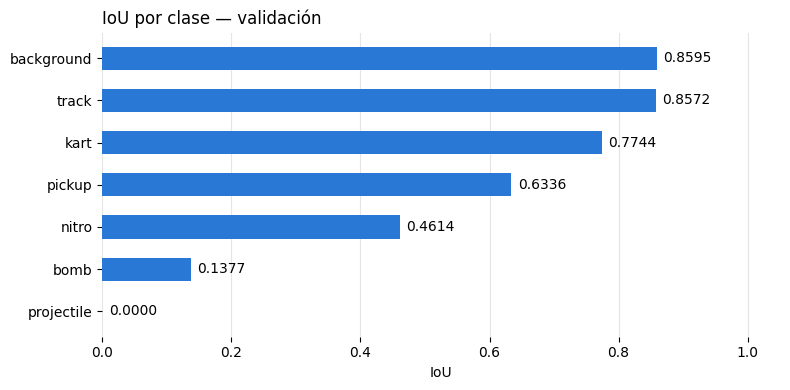

In [8]:
iou = [float(v) for v in cm.class_iou]
orden = np.argsort([v if v == v else -1 for v in iou])
fig, ax = plt.subplots(figsize=(8, 4))
ax.barh([CLASS_NAMES[i] for i in orden], [0 if iou[i] != iou[i] else iou[i] for i in orden],
        color='#2a78d6', height=0.55)
for y, i in enumerate(orden):
    v = iou[i]
    ax.text((0 if v != v else v) + 0.01, y, 'nan' if v != v else '%.4f' % v,
            va='center', fontsize=10)
ax.set_xlim(0, 1.05); ax.set_xlabel('IoU'); ax.set_title('IoU por clase — validación', loc='left')
for s in ax.spines.values(): s.set_visible(False)
ax.xaxis.grid(True, color='#e6e5e1'); ax.set_axisbelow(True)
fig.tight_layout(); plt.show()

### A dónde van los píxeles que falla

El IoU dice *qué* clase falla; esto dice *contra quién*, que es lo que decide el siguiente
experimento. Si los píxeles de `bomb` acaban en `background` es sub-detección; si acaban en
`nitro` es confusión entre objetos parecidos, y la solución es distinta.

In [9]:
print(format_confusion(cm))

--- a donde van los pixeles de cada clase real ---
background     46586947 px  ->  background 95.9%,  track 4.0%,  kart 0.0%
track          51786135 px  ->  track 88.9%,  background 10.3%,  kart 0.7%
kart            1754363 px  ->  kart 95.1%,  track 2.8%,  background 1.7%
pickup           112247 px  ->  pickup 82.6%,  background 13.0%,  nitro 2.2%
nitro              7645 px  ->  nitro 85.2%,  background 9.3%,  kart 3.3%
bomb              87841 px  ->  background 36.7%,  track 27.7%,  bomb 16.6%
projectile        16822 px  ->  background 50.6%,  kart 26.5%,  track 22.9%


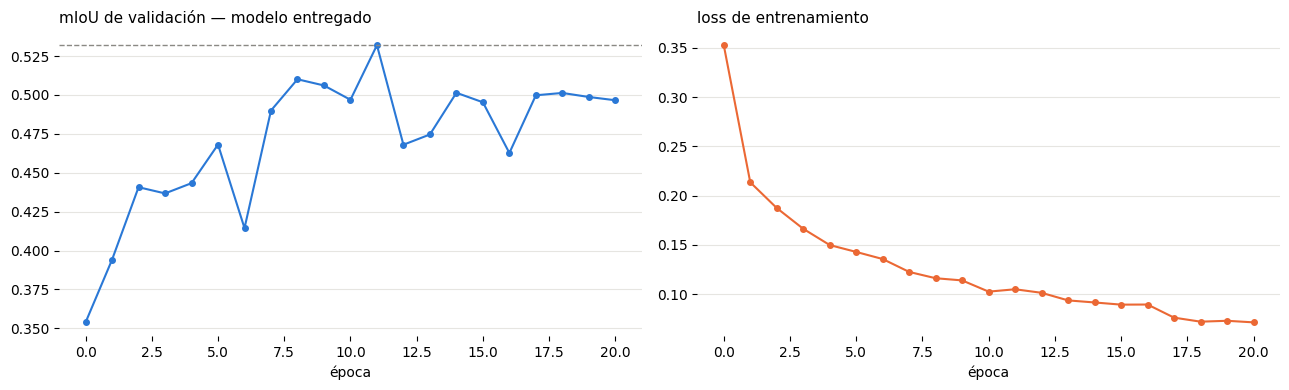

pico 0.5320 en la epoca 11 de 21


In [10]:
import csv, glob

COMBO = 'base_plus_s448_d256_lr0.0003_p0.20'
filas = [r for r in csv.DictReader(open('experimentos/resultados/epocas.csv'))
         if r['notes'] == COMBO]
filas.sort(key=lambda r: int(r['epoch']))

ep  = [int(r['epoch']) for r in filas]
mio = [float(r['val_miou']) for r in filas]
trl = [float(r['train_loss']) for r in filas]

fig, (a1, a2) = plt.subplots(1, 2, figsize=(13, 4))
a1.plot(ep, mio, '-o', color='#2a78d6', ms=4)
a1.axhline(max(mio), color='#8a8984', lw=1, ls='--')
a1.set_title('mIoU de validación — modelo entregado', loc='left', fontsize=11)
a2.plot(ep, trl, '-o', color='#eb6834', ms=4)
a2.set_title('loss de entrenamiento', loc='left', fontsize=11)
for a in (a1, a2):
    a.set_xlabel('época'); a.yaxis.grid(True, color='#e6e5e1'); a.set_axisbelow(True)
    for s in a.spines.values(): s.set_visible(False)
fig.tight_layout(); plt.show()
print('pico %.4f en la epoca %d de %d' % (max(mio), ep[mio.index(max(mio))], len(ep)))

### Las 32 configuraciones probadas

Se barrieron backbone, resolución, anchura de la cabeza, learning rate y exponente de los
pesos de clase. La tabla de abajo resume el **efecto medio de cada eje**, que es más fiable
que el ranking individual: con σ ≈ 0.018 de ruido entre épocas, dos configuraciones que
difieran menos de ~0.036 son indistinguibles.

In [11]:
def num(v):
    try: return float(v)
    except: return float('nan')

def medias(filas, eje):
    g = {}
    for r in filas:
        v = num(r['best_miou'])
        if v == v and r.get(eje): g.setdefault(r[eje], []).append(v)
    o = sorted(g.items(), key=lambda kv: -sum(kv[1])/len(kv[1]))
    return '   '.join('%s=%.4f (n=%d)' % (k, sum(v)/len(v), len(v)) for k, v in o)

todas = list(csv.DictReader(open('experimentos/resultados/configuraciones.csv')))
print('%d configuraciones registradas' % len(todas))

rejilla1 = [r for r in todas if r['lote'] == '20260909_165356']
rejilla2 = [r for r in todas if r['lote'] == '20260909_183741']

print()
print('REJILLA 1 (%d combos: backbone x dim x lr x power, todo a 448)' % len(rejilla1))
for eje in ['backbone', 'dim', 'lr', 'weight_power']:
    print('  %-14s %s' % (eje, medias(rejilla1, eje)))

print()
print('REJILLA 2 (%d combos: backbone x size x dim)' % len(rejilla2))
for eje in ['size', 'dim', 'backbone']:
    print('  %-14s %s' % (eje, medias(rejilla2, eje)))

print()
print('Cada eje se promedia SOLO dentro de la rejilla donde esta cruzado. Mezclar')
print('rejillas desbalanceadas invierte conclusiones: las corridas a 1024 solo se')
print('hicieron con las configuraciones buenas.')

print()
print('Con sigma ~0.018 entre epocas, dos configuraciones que difieran menos de')
print('~0.036 son indistinguibles. Las medias por eje (8-12 corridas) tienen error')
print('tipico ~0.006 y si distinguen efectos de +0.02.')

33 configuraciones registradas

REJILLA 1 (24 combos: backbone x dim x lr x power, todo a 448)
  backbone       large=0.5118 (n=8)   base_plus=0.5005 (n=8)   small=0.4921 (n=8)
  dim            256=0.5116 (n=12)   128=0.4914 (n=12)
  lr             0.0003=0.5020 (n=12)   0.001=0.5009 (n=12)
  weight_power   0.3=0.5016 (n=12)   0.2=0.5013 (n=12)

REJILLA 2 (7 combos: backbone x size x dim)
  size           1024=0.5146 (n=3)   448=0.5137 (n=4)
  dim            256=0.5211 (n=3)   512=0.5089 (n=4)
  backbone       large=0.5248 (n=3)   base_plus=0.5061 (n=4)

Cada eje se promedia SOLO dentro de la rejilla donde esta cruzado. Mezclar
rejillas desbalanceadas invierte conclusiones: las corridas a 1024 solo se
hicieron con las configuraciones buenas.

Con sigma ~0.018 entre epocas, dos configuraciones que difieran menos de
~0.036 son indistinguibles. Las medias por eje (8-12 corridas) tienen error
tipico ~0.006 y si distinguen efectos de +0.02.


## 6. Imágenes segmentadas

La demostración de que el modelo hace su trabajo. Los circuitos que se muestran **no se usaron
durante el entrenamiento**.

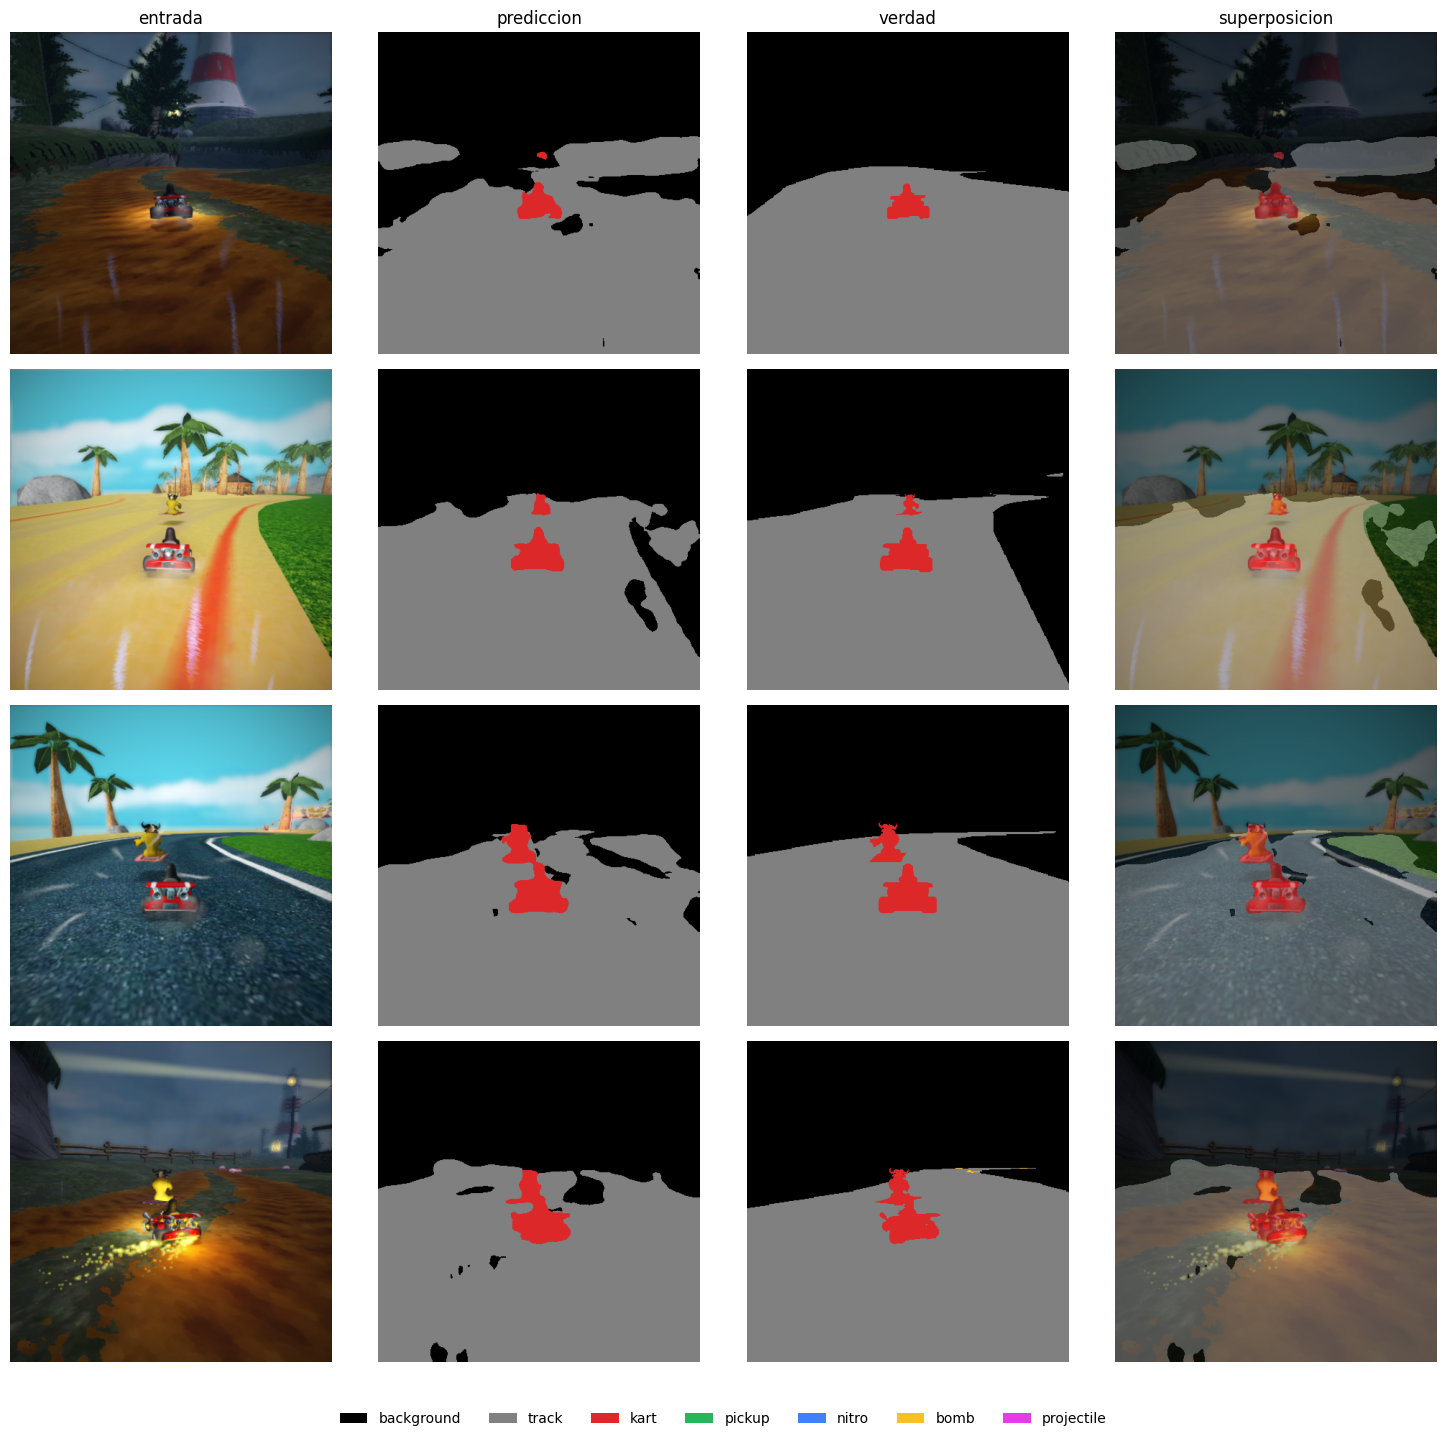

In [12]:
def segmentar(ds, idx):
    im, gt = ds[idx]
    with torch.no_grad():
        pred = modelo(im[None].to(device)).argmax(1)[0].cpu().numpy()
    return im, gt.numpy(), pred

elegidos = random.Random(3).sample(range(len(val_ds)), 4)
fig, axes = plt.subplots(len(elegidos), 4, figsize=(15, 3.6*len(elegidos)))
for r, idx in enumerate(elegidos):
    im, gt, pred = segmentar(val_ds, idx)
    inter = np.logical_and(pred == gt, gt > 0).sum()
    union = np.logical_or(pred > 0, gt > 0).sum()
    for c, (dat, tit) in enumerate([(im.permute(1,2,0).numpy(), 'entrada'),
                                    (label_to_color(pred), 'prediccion'),
                                    (label_to_color(gt), 'verdad'),
                                    (overlay(im.numpy(), pred), 'superposicion')]):
        axes[r, c].imshow(dat); axes[r, c].axis('off')
        if r == 0: axes[r, c].set_title(tit, fontsize=12)
    axes[r, 0].set_ylabel(os.path.basename(val_ds.samples[idx][0]), fontsize=8)
handles = [plt.Rectangle((0,0),1,1, fc=PALETTE[i]/255.) for i in range(NUM_CLASSES)]
fig.legend(handles, CLASS_NAMES, loc='lower center', ncol=7, frameon=False, fontsize=10)
fig.tight_layout(rect=[0, 0.04, 1, 1]); plt.show()

## 7. Conclusiones

### Resultado

**mIoU 0.5320** sobre 500 frames de dos circuitos que el modelo nunca vio, entrenando el
**3.6% del modelo** (2.56 M de 71.67 M). El encoder de SAM 2 permanece congelado por completo.

### Comparación con el baseline

El mismo dataset, con el mismo split por circuito, se resolvió antes con una U-Net entrenada
desde cero:

| clase | U-Net desde cero | SAM 2 | |
|---|---|---|---|
| background | 0.7768 | **0.8595** | +0.083 |
| track | 0.7365 | **0.8572** | +0.121 |
| kart | 0.6709 | **0.7744** | +0.104 |
| pickup | 0.5013 | **0.6336** | +0.132 |
| bomb | 0.0194 | **0.1377** | +0.118 |
| nitro | **0.5352** | 0.4614 | −0.074 |
| projectile | 0.0000 | 0.0000 | — |
| **mIoU** | 0.4629 | **0.5320** | **+0.069** |

Un **15% relativo de mejora**, ganando en 5 de las 7 clases. El error dominante de la U-Net era
confundir carretera con paisaje por brillo y textura en circuitos no vistos; con las features
de SAM 2, `track` pasa de 0.7365 a 0.8572.

### Qué mueve la aguja y qué no

Se probaron 32 configuraciones. Los únicos ejes con efecto real son los de **capacidad**:

| eje | efecto |
|---|---|
| backbone `small` → `large` | **+0.020** |
| `dim` 128 → 256 | **+0.020** |
| `dim` 256 → 512 | −0.012, se agota |
| resolución 448 → 1024 | +0.001 por 5–7× el coste |
| learning rate 1e-3 ↔ 3e-4 | 0.001, nada |
| exponente de pesos 0.20 ↔ 0.30 | 0.000, nada |

Las señales tempranas engañan: en la época 12 parecía claro que `lr=3e-4` y `power=0.20`
ganaban, y al converger resultaron indistinguibles. Lo que se ve pronto es velocidad de
convergencia, no calidad final.

### Descongelar el encoder no ayuda

Se probó descongelar el cuello FPN (0.3% del encoder) con learning rate diez veces menor que
la cabeza, midiendo el congelado como control en el mismo barrido: **−0.017 de mIoU y el doble
de inestabilidad** (σ 0.033 contra 0.016). Con 1000 imágenes de 4 circuitos y una brecha
`train`/`val` de 16.7×, adaptar los pesos preentrenados solo añade sobreajuste.

El código lo soporta (`--modos none neck bN`, `--encoder-lr`) y queda como trabajo futuro
reproducible.

### Sobre la fiabilidad de estas cifras

La desviación típica del mIoU entre épocas consecutivas es **σ ≈ 0.018**, así que dos
configuraciones que difieran menos de ~0.036 son indistinguibles. Por eso las decisiones se
tomaron con las **medias por eje** (8–12 corridas cada una, error típico ~0.006) y no con el
ranking individual.

Y el 0.5320 es el máximo de unas 800 evaluaciones, así que está optimistamente sesgado. El
nivel esperado de esta configuración, medido como media de las 5 mejores épocas, es **~0.518**
— confirmado por dos corridas independientes que dieron 0.5182 y 0.5179.

### Límite del dataset, no del modelo

`projectile` aparece en **1 frame de los 1000** de entrenamiento y `bomb` en 168. Ninguna
arquitectura aprende una clase que casi no existe. Aun así, una de las configuraciones
descartadas (`large`, `lr` 3e-4) llegó a **0.2422 de IoU en `projectile`** partiendo de ese
único ejemplo, algo que la U-Net nunca logró en 22 configuraciones.